In [ ]:
from __future__ import annotations
import math
import random
import networkx as nx
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RXGate,RYGate
from classical_runtime_guarantee_util import mvc_exact_cplex, mvc_lp_relaxation, greedy_degree_vertex_cover, greedy_edge_vertex_cover,mvc_primal_dual_weighted
from quantum_greedy_util import expectation_value_cost_shifted
# ----------------------
# Mixer construction
# ----------------------
def node_order_by_cost_degree(G, C):
    """Order nodes by descending cost and degree."""
    return sorted(G.nodes(), key=lambda i: (-C[i], G.degree(i)))

def mixer_from_graph(G, C, node_order=None, p=1):
    """Construct QAOA-style mixer circuit for MVC."""
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    for i in range(n):
        qc.x(i)

    if node_order is None:
        node_order = node_order_by_cost_degree(G, C)

    for _ in range(p):
        for tgt in node_order:
            angle = 2 * betas[tgt] / p
            ctrls = list(G.neighbors(tgt))
            if ctrls:
                qc.append(RYGate(angle).control(len(ctrls)), ctrls + [tgt])
            else:
                qc.ry(angle, tgt)

    return qc, betas, G




    

In [2]:
from collections import defaultdict
def conditional_smc_mvc_removal(G, beta_values, C, k=1, node_order=None, num_particles=100):
    """
    Sequential Monte Carlo along quantum tree, returns expectation value directly
    """
    if node_order is None:
        node_order = list(G.nodes())

    # Initialize particles: all vertices in cover
    particles = [{v: 1 for v in G.nodes()} for _ in range(num_particles)]

    for _ in range(k):
        for v in node_order:
            theta_v = beta_values[v]/k
            cos2 = math.cos(theta_v)**2
            sin2 = math.sin(theta_v)**2

            for p in range(num_particles):
                assigned = particles[p]

                # Check if removal is allowed (all neighbors still in cover)
                removable = all(assigned[u] == 1 for u in G.neighbors(v))

                if removable:
                    # Branch according to quantum amplitudes
                    choice = random.choices([1, 0], weights=[cos2, sin2])[0]
                else:
                    choice = 1

                assigned[v] = choice



    # Compute expectation value directly
    exp_val = 0.0
    for p in range(num_particles):
        particle_cost = sum(C[v] for v, val in particles[p].items() if val == 1)
        exp_val += particle_cost/num_particles
    

    weights = np.ones(num_particles)  # Uniform weights since we compute expectation directly
    return exp_val, particles, weights

In [4]:
import numpy as np
import math
import random
from collections import defaultdict
import copy

def mc_importance_sampling_paths(G, beta_values, C, k=1, node_order=None, num_particles=100):
    """
    Monte Carlo importance sampling over paths for multi-layer constrained RY ansatz.

    Returns:
        exp_val : approximate expectation value of cost
        leaf_amplitudes : dict mapping bitstring -> sum of sampled amplitudes
        leaf_probs : dict mapping bitstring -> approximate probability
    """
    if node_order is None:
        node_order = list(G.nodes())

    # Each particle is a dict of vertex -> 1/0 and associated amplitude
    particles = [{'assigned': {v: 1 for v in G.nodes()}, 'amp': 1.0} for _ in range(num_particles)]

    for layer in range(k):
        for v in node_order:
            theta_v = beta_values[v] / k
            cos2 = math.cos(theta_v)
            sin2 = math.sin(theta_v)

            new_particles = []
            for p in particles:
                assigned = p['assigned']
                amp = p['amp']
                
                removable = all(assigned[u] == 1 for u in G.neighbors(v))
                
                if removable:
                    # Branch left (keep 1)
                    p_left = copy.deepcopy(assigned)
                    p_left[v] = 1
                    new_particles.append({'assigned': p_left, 'amp': amp * cos2})

                    # Branch right (flip to 0)
                    p_right = copy.deepcopy(assigned)
                    p_right[v] = 0
                    new_particles.append({'assigned': p_right, 'amp': amp * sin2})
                else:
                    # Only left branch allowed
                    assigned[v] = 1
                    new_particles.append({'assigned': copy.deepcopy(assigned), 'amp': amp * 1.0})

            # Keep at most num_particles by random subsampling if too many
            if len(new_particles) > num_particles:
                new_particles = random.choices(new_particles, k=num_particles)

            particles = new_particles

    # Merge amplitudes for identical leaves
    leaf_amplitudes = defaultdict(float)
    for p in particles:
        bitstring = ''.join(str(p['assigned'][v]) for v in node_order)
        leaf_amplitudes[bitstring] += p['amp']

    # Convert to probabilities
    probs = {}
    norm = sum(abs(a)**2 for a in leaf_amplitudes.values())
    for k, a in leaf_amplitudes.items():
        probs[k] = (abs(a)**2)/norm

    # Compute expected cost
    exp_val = 0.0
    for bitstring, prob in probs.items():
        cost = sum(C[v] for v, b in zip(node_order, bitstring) if b == '1')
        exp_val += prob * cost

    return exp_val, leaf_amplitudes, probs

In [7]:
def smc_with_weight_merging(G, beta_values, C, k=1, node_order=None, num_particles=100):
    """
    Sequential Monte Carlo with weighted particle merging for multi-layer constrained RY ansatz.

    Returns:
        exp_val : approximate expectation value
        particles : list of final leaf bitstrings
        weights : normalized weights for each leaf
    """
    if node_order is None:
        node_order = list(G.nodes())

    # Initialize particles: all vertices in cover
    particles = [{v: 1 for v in G.nodes()} for _ in range(num_particles)]
    weights = np.ones(num_particles)  # start uniform

    for layer in range(k):
        for v in node_order:
            theta_v = beta_values[v] / k
            cos2 = math.cos(theta_v)
            sin2 = math.sin(theta_v)

            # Update particles
            new_particles = []
            new_weights = []

            for p, w in zip(particles, weights):
                assigned = p
                removable = all(assigned[u] == 1 for u in G.neighbors(v))

                if removable:
                    # Left branch
                    p_left = copy.deepcopy(assigned)
                    p_left[v] = 1
                    new_particles.append(p_left)
                    new_weights.append(w * cos2)

                    # Right branch
                    p_right = copy.deepcopy(assigned)
                    p_right[v] = 0
                    new_particles.append(p_right)
                    new_weights.append(w * sin2)
                else:
                    # Only left
                    assigned[v] = 1
                    new_particles.append(copy.deepcopy(assigned))
                    new_weights.append(w * 1.0)

            # Keep number of particles fixed by resampling if necessary
            if len(new_particles) > num_particles:
                indices = np.random.choice(len(new_particles), size=num_particles, p=np.array(new_weights)/sum(new_weights))
                particles = [new_particles[i] for i in indices]
                weights = np.array([new_weights[i] for i in indices])
                weights /= np.sum(weights)
            else:
                particles = new_particles
                weights = np.array(new_weights)
                weights /= np.sum(weights)

    # Merge identical leaves
    merged = defaultdict(float)
    for p, w in zip(particles, weights):
        bitstring = ''.join(str(p[v]) for v in node_order)
        merged[bitstring] += w

    # Convert merged dict to list
    particles = list(merged.keys())
    weights = np.array(list(merged.values()))
    weights /= np.sum(weights)

    # Compute expectation
    exp_val = 0.0
    for bitstring, w in zip(particles, weights):
        cost = sum(C[v] for v, b in zip(node_order, bitstring) if b == '1')
        exp_val += w * cost

    return exp_val, particles, weights

In [8]:
G=nx.erdos_renyi_graph(8,0.3) # start small

In [ ]:
# --- Graph ---
G = nx.random_regular_graph(3,8)  

C = {v: 1 for v in G.nodes()}
beta_values = {v: math.pi/4 for v in G.nodes()}
p=4

# --- Build mixer circuit ---
qc, betas, G = mixer_from_graph(G, C,node_order=list(beta_values.keys()),p=p)

# --- Circuit expectation (your function) ---
E_circuit = expectation_value_cost_shifted(
    qc, betas, C, beta_values, shots=10000  # use None if exact backend
)

print("Circuit expectation:", E_circuit)

# --- Monte Carlo expectation ---
E_mc,particles,weights  = conditional_smc_mvc_removal(
        G,
        beta_values,
        C,
        k=p,
        node_order=list(betas.keys()),
        num_particles=10000
)
E,a,b=mc_importance_sampling_paths(G, beta_values, C, k=p, node_order=None, num_particles=10000)
E1,a,b=smc_with_weight_merging(G, beta_values, C, k=p, node_order=None, num_particles=10000)
#E_mc = monte_carlo_expectation(C, particles, weights)
print(E)
print(E1)
print("Monte Carlo expectation:", E_mc)
print("Absolute difference PIMC:", abs(E_circuit - E))
print("Absolute difference Sequential:", abs(E_circuit - E1))


Circuit expectation: 5.5597
7.835014610693385
7.951114814828784
Monte Carlo expectation: 7.7268
Absolute difference PIMC: 2.2753146106933846
Absolute difference Sequential: 2.3914148148287833


Exact circuit expectation: 8.738839015311683
Particles=10, Monte Carlo E=7.999615099005615, |Δ|=0.73922
Particles=10, Sampled E=9.0, |Δ|=0.26116
Particles=100, Monte Carlo E=9.874571936077942, |Δ|=1.13573
Particles=100, Sampled E=8.729999999999999, |Δ|=0.00884
Particles=1000, Monte Carlo E=9.629559841104125, |Δ|=0.89072
Particles=1000, Sampled E=8.720999999999997, |Δ|=0.01784
Particles=10000, Monte Carlo E=9.579826702220846, |Δ|=0.84099
Particles=10000, Sampled E=8.736899999999999, |Δ|=0.00194
Particles=100000, Monte Carlo E=9.95724882005934, |Δ|=1.21841
Particles=100000, Sampled E=8.74297, |Δ|=0.00413


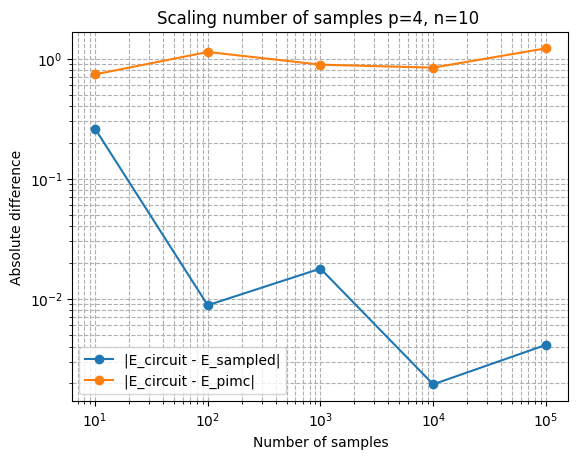

In [12]:
# --- Setup ---
import networkx as nx
import numpy as np
import math
import matplotlib.pyplot as plt
n = 10
G = nx.random_regular_graph(3, n)
C = {v: 1 for v in G.nodes()}
beta_values = {v: math.pi/8 for v in G.nodes()}
# --- Build mixer circuit ---
qc, betas, G = mixer_from_graph(G, C,node_order=list(beta_values.keys()),p=p)

# --- Exact circuit expectation ---
E_circuit = expectation_value_cost_shifted(qc, betas, C, beta_values, shots=None)
print("Exact circuit expectation:", E_circuit)

# --- Monte Carlo particle numbers ---
particle_counts = [10,100, 1000, 10000, 100000]

abs_diffs_sampled = []
abs_diffs = []
abs_diffs_pimc=[]
abs_diffs_seq=[]

for N in particle_counts:
    E_mc,particles,weights  = conditional_smc_mvc_removal(
        G,
        beta_values,
        C,
        k=p,
        node_order=list(betas.keys()),
        num_particles=N
    )
    E_sampled = expectation_value_cost_shifted(qc, betas, C, beta_values, shots=N)
    E_pimc,a,b=mc_importance_sampling_paths(G, beta_values, C, k=p, node_order=None, num_particles=N)
    #E_seq,a,b=smc_with_weight_merging(G, beta_values, C, k=p, node_order=None, num_particles=N)
    #E_mc = monte_carlo_expectation(C, particles, weights)
    #abs_diffs.append(abs(E_circuit - E_mc))
    abs_diffs_sampled.append(abs(E_circuit - E_sampled))
    abs_diffs_pimc.append(abs(E_circuit - E_pimc))
    #abs_diffs_seq.append(abs(E_circuit - E_seq))
    print(f"Particles={N}, Monte Carlo E={E_pimc}, |Δ|={abs_diffs_pimc[-1]:.5f}")
    print(f"Particles={N}, Sampled E={E_sampled}, |Δ|={abs_diffs_sampled[-1]:.5f}")

# --- Plot ---
plt.figure()
#plt.loglog(particle_counts, abs_diffs, marker='o', label="|E_circuit - E_MC|")
plt.loglog(particle_counts, abs_diffs_sampled, marker='o', label="|E_circuit - E_sampled|")
plt.loglog(particle_counts, abs_diffs_pimc, marker='o', label="|E_circuit - E_pimc|")
#plt.loglog(particle_counts, abs_diffs_seq, marker='o', label="|E_circuit - E_seq|")
plt.xlabel("Number of samples")
plt.ylabel("Absolute difference")
plt.title("Scaling number of samples p=4, n=10 ")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


Running experiments for p = 1
Size=6, p=1, avg |E_circuit - E_MC|=0.05882
Size=8, p=1, avg |E_circuit - E_MC|=0.07252
Size=10, p=1, avg |E_circuit - E_MC|=0.09888
Size=12, p=1, avg |E_circuit - E_MC|=0.10024
Size=14, p=1, avg |E_circuit - E_MC|=0.14173
Size=16, p=1, avg |E_circuit - E_MC|=0.16355

Running experiments for p = 2
Size=6, p=2, avg |E_circuit - E_MC|=1.24710
Size=8, p=2, avg |E_circuit - E_MC|=1.58665
Size=10, p=2, avg |E_circuit - E_MC|=1.92667
Size=12, p=2, avg |E_circuit - E_MC|=2.21466
Size=14, p=2, avg |E_circuit - E_MC|=2.69107
Size=16, p=2, avg |E_circuit - E_MC|=2.87977

Running experiments for p = 3
Size=6, p=3, avg |E_circuit - E_MC|=1.49947
Size=8, p=3, avg |E_circuit - E_MC|=1.88095
Size=10, p=3, avg |E_circuit - E_MC|=2.25268
Size=12, p=3, avg |E_circuit - E_MC|=2.54898
Size=14, p=3, avg |E_circuit - E_MC|=2.77012
Size=16, p=3, avg |E_circuit - E_MC|=3.33389

Running experiments for p = 4
Size=6, p=4, avg |E_circuit - E_MC|=1.50281
Size=8, p=4, avg |E_circuit 

ValueError: x and y must have same first dimension, but have shapes (6,) and (0,)

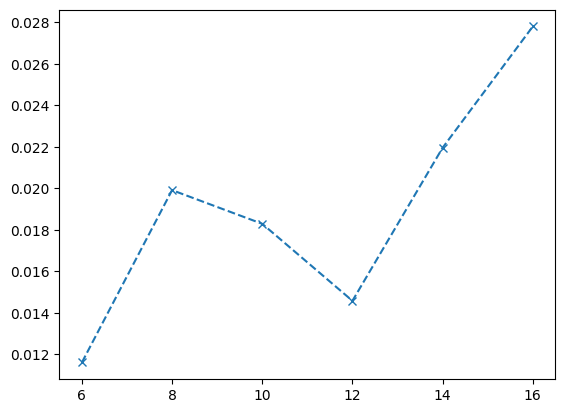

In [13]:
import networkx as nx
import numpy as np
import math
import matplotlib.pyplot as plt

# --- Experiment parameters ---
graph_sizes = [6, 8, 10, 12, 14, 16]
graphs_per_size = 30
N = 1000

p_values = [1, 2, 3, 4]   # <-- choose depths you want to compare

results_mc = {p: [] for p in p_values}
results_sampled = {p: [] for p in p_values}
results_pimc = {p: [] for p in p_values}
results_seq = {p: [] for p in p_values}

for p in p_values:
    print(f"\nRunning experiments for p = {p}")
    
    for n in graph_sizes:
        abs_diffs = []
        abs_diffs_sampled = []
        abs_diffs_pimc=[]
        abs_diffs_seq=[]
        
        for _ in range(graphs_per_size):
            
            # Generate random 3-regular graph
            G = nx.random_regular_graph(3, n)
            C = {v: 1 for v in G.nodes()}
            beta_values = {v: math.pi/4 for v in G.nodes()}
            
            # Build mixer circuit
            qc, betas, G = mixer_from_graph(
                G,
                C,
                node_order=list(beta_values.keys()),
                p=p
            )
            
            # Exact expectation
            E_circuit = expectation_value_cost_shifted(
                qc, betas, C, beta_values, shots=None
            )
            
            # Shot-based sampling
            E_sampled = expectation_value_cost_shifted(
                qc, betas, C, beta_values, shots=N
            )
            '''
            # Monte Carlo tree estimator
            E_mc, particles, weights = conditional_smc_mvc_removal(
                G,
                beta_values,
                C,
                k=p,
                node_order=list(betas.keys()),
                num_particles=N
            )
            '''
            E_pimc,a,b=mc_importance_sampling_paths(G, beta_values, C, k=p, node_order=None, num_particles=N)
            #E_seq,a,b=smc_with_weight_merging(G, beta_values, C, k=p, node_order=None, num_particles=N)
            #E_mc = monte_carlo_expectation(C, particles, weights)
            #abs_diffs.append(abs(E_circuit - E_mc))
            abs_diffs_sampled.append(abs(E_circuit - E_sampled))
            abs_diffs_pimc.append(abs(E_circuit - E_pimc))
            #abs_diffs_seq.append(abs(E_circuit - E_seq))
        
        #results_mc[p].append(np.mean(abs_diffs))
        results_sampled[p].append(np.mean(abs_diffs_sampled))
        results_pimc[p].append(np.mean(abs_diffs_pimc))
        #results_seq[p].append(np.mean(abs_diffs_seq))
        print(f"Size={n}, p={p}, avg |E_circuit - E_MC|={results_pimc[p][-1]:.5f}")

# --- Plot ---
plt.figure()

for p in p_values:
    '''
    plt.plot(
        graph_sizes,
        results_mc[p],
        marker='o',
        label=f"MC error (p={p})"
    )
    '''
    plt.plot(
        graph_sizes,
        results_sampled[p],
        marker='x',
        linestyle='--',
        label=f"Shot error (p={p})"
    )

    plt.plot(
        graph_sizes,
        results_seq[p],
        marker='x',
        linestyle='--',
        label=f"PIMC error (p={p})"
    )
    '''
    plt.plot(
        graph_sizes,
        results_pimc[p],
        marker='x',
        linestyle='--',
        label=f"Seq error (p={p})"
    )
    '''
plt.xlabel("Graph size n")
plt.ylabel("Average absolute difference")
plt.title("N_samples=10000")
plt.legend()
plt.grid(True)
plt.show()

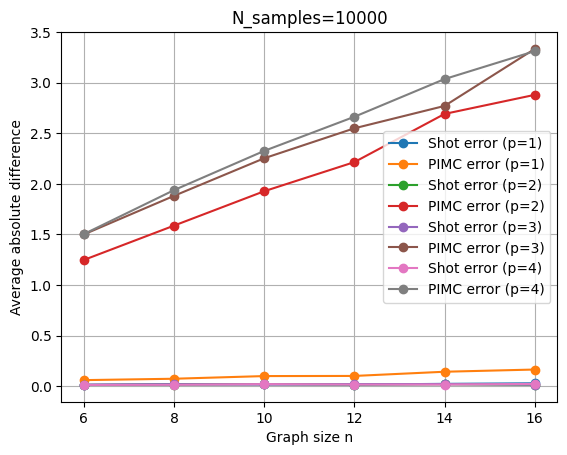

In [17]:
for p in p_values:
    '''
    plt.plot(
        graph_sizes,
        results_mc[p],
        marker='o',
        label=f"MC error (p={p})"
    )
    '''
    plt.plot(
        graph_sizes,
        results_sampled[p],
        marker='o',
        linestyle='-',
        label=f"Shot error (p={p})"
    )
    plt.plot(
        graph_sizes,
        results_pimc[p],
        marker='o',
        linestyle='-',
        label=f"PIMC error (p={p})"
    )
plt.xlabel("Graph size n")
plt.ylabel("Average absolute difference")
plt.title("N_samples=10000")
plt.legend()
plt.grid(True)
plt.show()

p=1, average |E_circuit - E_sampled|=0.00620
p=1, average |E_circuit - E_pimc|=0.07857
p=2, average |E_circuit - E_sampled|=0.00624
p=2, average |E_circuit - E_pimc|=1.98196
p=3, average |E_circuit - E_sampled|=0.00471
p=3, average |E_circuit - E_pimc|=2.25310
p=4, average |E_circuit - E_sampled|=0.00256
p=4, average |E_circuit - E_pimc|=1.95126
p=5, average |E_circuit - E_sampled|=0.00303
p=5, average |E_circuit - E_pimc|=2.46631
p=6, average |E_circuit - E_sampled|=0.00387
p=6, average |E_circuit - E_pimc|=2.31348


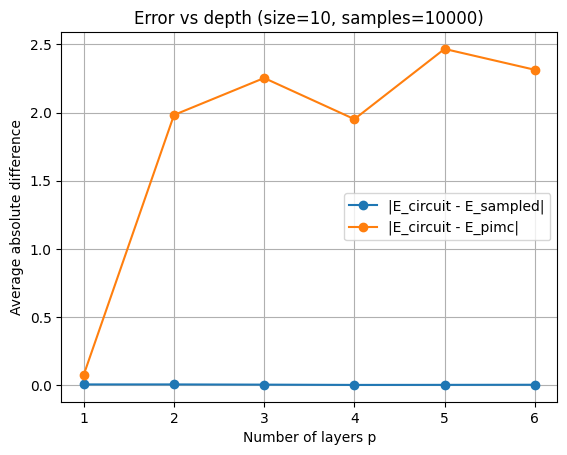

In [18]:
import networkx as nx
import numpy as np
import math
import matplotlib.pyplot as plt

# --- Fixed parameters ---
n = 10                      # fixed graph size
graphs_per_setting = 5    # average over multiple graphs
num_particles = 10000     # fixed SMC particles
shots = 10000          # fixed circuit sampling shots

p_values = [1, 2, 3, 4, 5, 6]

avg_abs_diffs = []
avg_abs_diffs_sampled = []
avg_abs_diffs_pimc = []
avg_abs_diffs_seq = []


for p in p_values:
    abs_diffs = []
    abs_diffs_sampled = []
    abs_diffs_pimc = []
    abs_diffs_seq = []

    for _ in range(graphs_per_setting):

        # Generate random 3-regular graph
        G = nx.random_regular_graph(3, n)
        C = {v: 1 for v in G.nodes()}
        beta_values = {v: math.pi/4 for v in G.nodes()}

        # Build mixer circuit with p layers
        qc, betas, G = mixer_from_graph(
            G,
            C,
            node_order=list(G.nodes()),
            p=p
        )

        # Exact circuit expectation
        E_circuit = expectation_value_cost_shifted(
            qc,
            betas,
            C,
            beta_values,
            shots=None
        )

        # Shot-based circuit sampling
        E_sampled = expectation_value_cost_shifted(
            qc,
            betas,
            C,
            beta_values,
            shots=shots
        )
        '''
        # Monte Carlo SMC
        E_mc, particles, weights = conditional_smc_mvc_removal(
            G,
            beta_values,
            C,
            k=p,                      # IMPORTANT: consistent naming
            node_order=list(G.nodes()),
            num_particles=num_particles
        )
        '''
        E_pimc,a,b=mc_importance_sampling_paths(G, beta_values, C, k=p, node_order=None, num_particles=N)
        E_seq,a,b=smc_with_weight_merging(G, beta_values, C, k=p, node_order=None, num_particles=N)
        #E_mc = monte_carlo_expectation(C, particles, weights)
        #abs_diffs.append(abs(E_circuit - E_mc))
        abs_diffs_sampled.append(abs(E_circuit - E_sampled))
        abs_diffs_pimc.append(abs(E_circuit - E_pimc))
        #abs_diffs_seq.append(abs(E_circuit - E_seq))

    #avg_abs_diffs.append(np.mean(abs_diffs))
    avg_abs_diffs_sampled.append(np.mean(abs_diffs_sampled))
    #avg_abs_diffs_seq.append(np.mean(abs_diffs_seq))
    avg_abs_diffs_pimc.append(np.mean(abs_diffs_pimc))

    #print(f"p={p}, average |E_circuit - E_MC|={avg_abs_diffs[-1]:.5f}")
    print(f"p={p}, average |E_circuit - E_sampled|={avg_abs_diffs_sampled[-1]:.5f}")
    #print(f"p={p}, average |E_circuit - E_seq|={avg_abs_diffs_seq[-1]:.5f}")
    print(f"p={p}, average |E_circuit - E_pimc|={avg_abs_diffs_pimc[-1]:.5f}")

# --- Plot ---
plt.figure()
#plt.plot(p_values, avg_abs_diffs, marker='o', label="|E_circuit - E_MC|")
plt.plot(p_values, avg_abs_diffs_sampled, marker='o', label="|E_circuit - E_sampled|")
plt.plot(p_values, avg_abs_diffs_pimc, marker='o', label="|E_circuit - E_pimc|")
#plt.plot(p_values, avg_abs_diffs_seq, marker='o', label="|E_circuit - E_seq|")
plt.xlabel("Number of layers p")
plt.ylabel("Average absolute difference")
plt.title(f"Error vs depth (size={n}, samples={num_particles})")
plt.grid(True)
plt.legend()
plt.show()

In [21]:
import networkx as nx
import numpy as np
import math
import matplotlib.pyplot as plt

# --- Fixed parameters ---
n = 10
graphs_per_setting = 5
num_particles = 10000
shots = 10000

p_values = [1, 2, 3, 4]          # depths to compare
num_beta_points = 15
beta_sweep = np.linspace(0, math.pi, num_beta_points)

results_mc = {p: [] for p in p_values}
results_sampled = {p: [] for p in p_values}
results_pimc = {p: [] for p in p_values}
results_seq = {p: [] for p in p_values}

for p in p_values:
    print(f"\nRunning experiments for p = {p}")

    for beta in beta_sweep:
        abs_diffs = []
        abs_diffs_sampled = []
        abs_diffs_seq= []
        abs_diffs_pimc = []

        for _ in range(graphs_per_setting):

            G = nx.random_regular_graph(3, n)
            C = {v: 1 for v in G.nodes()}
            beta_values = {v: beta for v in G.nodes()}

            qc, betas, G = mixer_from_graph(
                G,
                C,
                node_order=list(G.nodes()),
                p=p
            )

            # Exact expectation
            E_circuit = expectation_value_cost_shifted(
                qc,
                betas,
                C,
                beta_values,
                shots=None
            )

            # Shot-based sampling
            E_sampled = expectation_value_cost_shifted(
                qc,
                betas,
                C,
                beta_values,
                shots=shots
            )
            '''
            # SMC
            E_mc, particles, weights = conditional_smc_mvc_removal(
                G,
                beta_values,
                C,
                k=p,
                node_order=list(G.nodes()),
                num_particles=num_particles
            )
            '''
            E_pimc,a,b=mc_importance_sampling_paths(G, beta_values, C, k=p, node_order=None, num_particles=N)
            #E_seq,a,b=smc_with_weight_merging(G, beta_values, C, k=p, node_order=None, num_particles=N)
            #E_mc = monte_carlo_expectation(C, particles, weights)
            #abs_diffs.append(abs(E_circuit - E_mc))
            abs_diffs_sampled.append(abs(E_circuit - E_sampled))
            abs_diffs_pimc.append(abs(E_circuit - E_pimc))
            #abs_diffs_seq.append(abs(E_circuit - E_seq))


        #results_mc[p].append(np.mean(abs_diffs))
        results_sampled[p].append(np.mean(abs_diffs_sampled))
        results_pimc[p].append(np.mean(abs_diffs_pimc))
        #results_seq[p].append(np.mean(abs_diffs_seq))

        print(f"  beta={beta:.3f}  MC error={results_pimc[p][-1]:.5f}")

# --- Plot ---
plt.figure()

for p in p_values:
    plt.plot(
        beta_sweep,
        results_mc[p],
        marker='o',
        label=f"SMC error (p={p})"
    )

plt.plot(
    beta_sweep,
    results_sampled[p_values[0]],
    linestyle='--',
    color='black',
    label="Shot sampling error"
)

plt.xlabel("alpha")
plt.ylabel("Average absolute difference")
plt.title(f"Error vs parameters for multiple depths (n={n}, samples={num_particles})")
plt.grid(True)
plt.legend()
plt.show()


Running experiments for p = 1
  beta=0.000  MC error=0.00000
  beta=0.224  MC error=0.10479
  beta=0.449  MC error=0.08639
  beta=0.673  MC error=0.08508
  beta=0.898  MC error=0.04995
  beta=1.122  MC error=0.09798
  beta=1.346  MC error=0.27331
  beta=1.571  MC error=0.00000
  beta=1.795  MC error=0.14724
  beta=2.020  MC error=0.15908
  beta=2.244  MC error=0.07481
  beta=2.468  MC error=0.04620
  beta=2.693  MC error=0.18532
  beta=2.917  MC error=0.11149
  beta=3.142  MC error=0.00000

Running experiments for p = 2


ZeroDivisionError: float division by zero